1-INTRODUCTION - Life Expectancy and Economic Indicators 

This project explores how economic factors such as GDP per capita, health expenditure, and population relate to life expectancy.

The goal is to understand whether economic indicators can help predict life expectancy using a regression model.



2-BUSINESS QUESTIONS

This project aims to explore the relationship between economic indicators and life expectancy.

The main questions of this analysis are:

1. What is the distribution of life expectancy in the dataset?
2. Is there a relationship between GDP per capita and life expectancy?
3. Does healthcare spending influence life expectancy?
4. Can economic indicators help predict life expectancy using a machine learning model?

3-DATA UNDERSTANDING & DATA LOADING

The dataset contains economic and health-related indicators for different countries.

Main variables used in this project include:

- GDP per capita
- Health expenditure per capita
- Life expectancy

These variables help us explore whether economic conditions are related to life expectancy.

In [3]:
#Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [4]:
df = pd.read_csv("../data/economic_life_expectancy_dataset.csv")

In [5]:
df.head()

,country,year,gdp_per_capita,health_expenditure_per_capita,population_millions,life_expectancy
0,USA,2010,26014.51,6324.28,238.60,77.48
1,USA,2011,30565.00,6052.93,247.46,78.23
2,USA,2012,31590.16,6437.18,239.81,77.52
3,USA,2013,29053.95,6877.25,240.87,77.14
4,USA,2014,29771.87,6291.21,240.88,77.31


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        100 non-null    object 
 1   year                           100 non-null    int64  
 2   gdp_per_capita                 100 non-null    float64
 3   health_expenditure_per_capita  100 non-null    float64
 4   population_millions            100 non-null    float64
 5   life_expectancy                100 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


In [7]:
df.describe()

,year,gdp_per_capita,health_expenditure_per_capita,population_millions,life_expectancy
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,2014.500000,30797.136400,3874.519600,225.325600,74.85610
std,2.886751,15695.643863,1715.355938,76.909337,4.49216
min,2010.000000,13490.240000,1493.400000,51.240000,67.69000
25%,2012.000000,18532.070000,2059.012500,206.390000,71.04750
50%,2014.500000,25811.885000,3616.365000,244.770000,74.81000
75%,2017.000000,37672.917500,5434.200000,283.920000,78.46500
max,2019.000000,66038.030000,7382.810000,325.070000,82.02000


4- DATASET OVERVIEW & MISSING VALUE CHECK

The dataset contains information about several countries and years. It includes economic indicators such as GDP per capita, health expenditure per capita, and population size.

The target variable in this analysis is life expectancy, which represents the average number of years people are expected to live.

From the summary statistics, we can observe the range and average values of each variable. This helps us understand the general structure of the dataset.

In [8]:
df.isnull().sum()

country                          0
year                             0
gdp_per_capita                   0
health_expenditure_per_capita    0
population_millions              0
life_expectancy                  0
dtype: int64

#Missing Values

The dataset was checked for missing values using the `isnull()` function.

The results show that there are no missing values in the dataset. Therefore, no additional data cleaning was required for missing data.

5- EDA

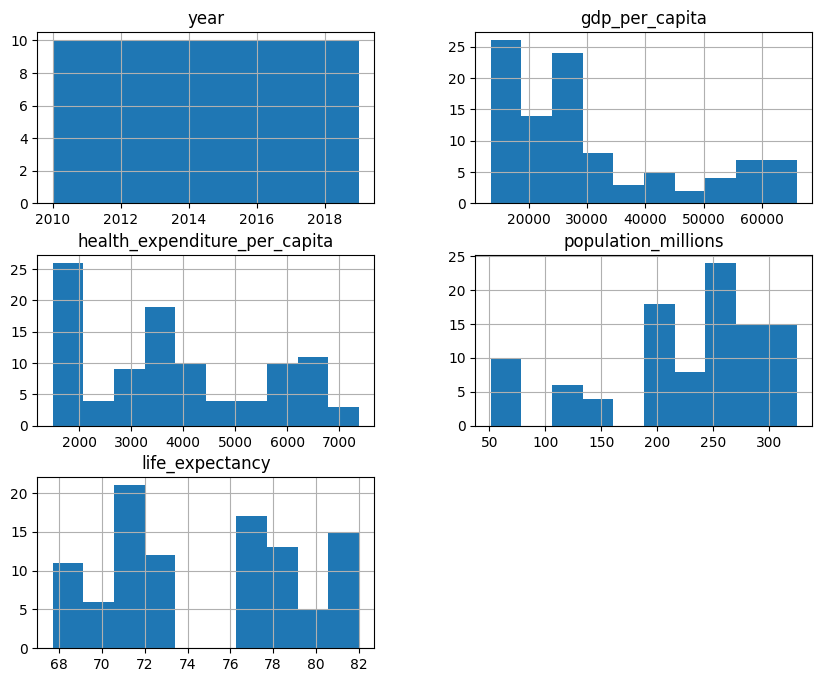

In [9]:
#EDA

df.hist(figsize=(10,8))
plt.show()

Distribution of Variables

The histograms help us understand how the data is distributed.

- GDP per capita shows how income levels vary across countries.
- Health expenditure shows how much countries spend on healthcare.
- Population shows the size of different countries.
- Life expectancy shows how long people live on average.

These distributions help us understand the variability in the dataset and detect possible outliers.

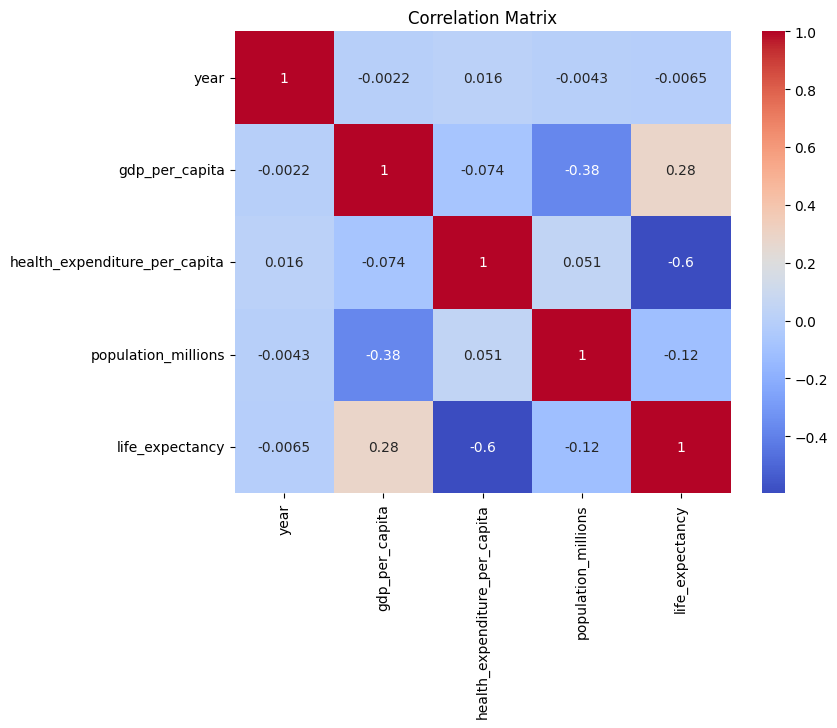

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#Correlation Analysis

The correlation heatmap shows the relationship between the variables in the dataset.

We can observe that **GDP per capita** and **health expenditure** have a positive relationship with **life expectancy**. This suggests that countries with stronger economies and higher healthcare spending may have higher life expectancy.

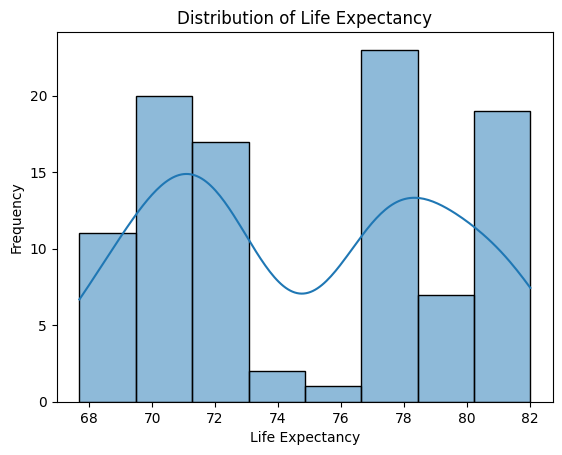

In [11]:
#Life Expectancy Distribution

sns.histplot(df["life_expectancy"], kde=True)
plt.title("Distribution of Life Expectancy")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.show()

#Life Expectancy Distribution

This histogram shows the distribution of life expectancy values in the dataset. 

Most values are concentrated within a certain range, which suggests that life expectancy values across the dataset are relatively consistent with some variation between countries.

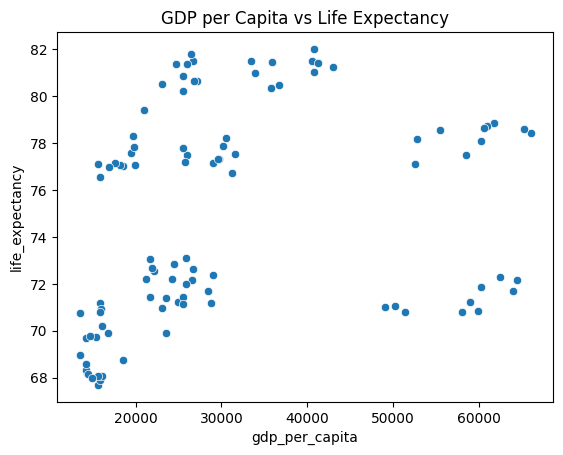

In [12]:
#GDP vs Life Expectancy

sns.scatterplot(x="gdp_per_capita", y="life_expectancy", data=df)
plt.title("GDP per Capita vs Life Expectancy")
plt.show()

#Relationship between GDP and Life Expectancy

This scatter plot shows the relationship between GDP per capita and life expectancy.

We can observe a general upward trend, suggesting that countries with higher income levels may also have higher life expectancy.

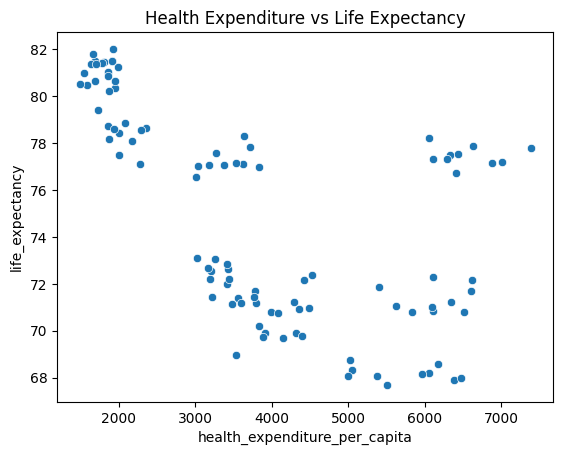

In [13]:
#Health Spending vs Life Expectancy

sns.scatterplot(x="health_expenditure_per_capita", y="life_expectancy", data=df)
plt.title("Health Expenditure vs Life Expectancy")
plt.show()

6- DATA PREPARATION

Before building the machine learning model, the dataset needs to be prepared.

In this step:

- The target variable (life expectancy) is separated.
- The remaining variables are used as features.
- The dataset is split into training and testing sets.

In [14]:
X = df[["gdp_per_capita", "health_expenditure_per_capita", "population_millions"]]
y = df["life_expectancy"]

In [15]:
#Train Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

7- ML MODEL

In [16]:
#Model

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
#model prediction

y_pred = model.predict(X_test)

8- MODEL EVALUATION

In [18]:
#model evaluation
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(y_test, predictions):
    """
    Evaluate regression model performance.

    Parameters
    ----------
    y_test : array
        Actual values

    predictions : array
        Predicted values

    Returns
    -------
    mse : float
        Mean Squared Error
    r2 : float
        R-squared score
    """

    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    return mse, r2

In [20]:
mse, r2 = evaluate_model(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 9.79215755656681
R2: 0.3118598777146603


#Model Evaluation

The model achieved a Mean Squared Error (MSE) of approximately 9.79 and an R² score of 0.31.

This means that the model explains about 31% of the variation in life expectancy based on the economic indicators used in this analysis.

While the model captures some relationship between the variables, there are likely additional factors influencing life expectancy that are not included in this dataset.

In [21]:
#If a country has a GDP per capita of 30,000, health spending of 2,000, and a population of 50 million, how much life expectancy does the model predict?

new_country = [[30000, 2000, 50]]

prediction = model.predict(new_country)

print("Predicted Life Expectancy:", prediction)


Predicted Life Expectancy: [77.37993732]


/opt/venv/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


9- PREDICTION SCENARIO

To demonstrate the model's usage, we created a simple prediction scenario.

Given a country with specific economic indicators, the model can estimate its expected life expectancy.

10- CONCLUSION

This project explored the relationship between economic indicators and life expectancy.

The analysis showed that GDP per capita and healthcare expenditure appear to have a positive relationship with life expectancy.

A simple machine learning model was also built to predict life expectancy. The model achieved an R² score of approximately 0.31, indicating that economic factors explain part of the variation in life expectancy.

Future work could include additional variables such as education, lifestyle factors, or environmental indicators to improve prediction performance.